<a href="https://colab.research.google.com/github/keidenmw21-prog/MIS433/blob/main/Customer_Churn_Competition_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom Churn Prediction

In [17]:
!pip install lightgbm -q
import pandas as pd, numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb, lightgbm as lgb
from sklearn.model_selection import cross_val_score


In [18]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/My Drive/Colab Notebooks/Data/'  # adjust if files are in a subfolder


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
churn_train  = pd.read_csv(DATA_DIR + 'churn_train.csv')
churn_test   = pd.read_csv(DATA_DIR + 'churn_test.csv')
accounts     = pd.read_csv(DATA_DIR + 'accounts.csv').drop_duplicates(subset='CustomerNo')
demographics = pd.read_csv(DATA_DIR + 'demographics.csv').drop_duplicates(subset='CustomerNo')
services     = pd.read_csv(DATA_DIR + 'services.csv').drop_duplicates(subset='CustomerNo')

def build_df(base):
    df = base.merge(accounts,     on='CustomerNo', how='left')
    df = df.merge(demographics,   on='CustomerNo', how='left')
    df = df.merge(services,       on='CustomerNo', how='left')
    return df

train = build_df(churn_train)
test  = build_df(churn_test)

print(train.shape, test.shape)
train.head()


(4238, 18) (1060, 17)


,CustomerNo,Churn,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod,Country,State,Retired,HasPartner,HasDependents,Education,Gender,TypeOfService,SeviceDetails
0,1201,0,478.50,5-1-2012,5920.00,10-Jan-11,No,One year,Electronic check,India,Maharashtra,0,2,2,Masters,Male,DeviceProtection,Yes
1,1202,0,103.25,5-1-2012,103.25,6-Dec-11,No,Month-to-month,Electronic check,India,Maharashtra,0,2,2,ProfessionalQalification,Male,DeviceProtection,No internet service
2,1205,1,372.50,5-1-2012,372.50,6-Dec-11,Yes,Month-to-month,Electronic check,India,Maharashtra,0,2,2,ProfessionalQalification,Female,DeviceProtection,No
3,1206,0,99.50,5-1-2012,6775.50,7-Mar-06,Yes,Two year,Credit card (automatic),India,Maharashtra,0,2,2,Highschool or below,Male,DeviceProtection,No internet service
4,1207,0,91.25,5-1-2012,2673.50,17-Sep-09,No,One year,Credit card (automatic),India,Maharashtra,0,2,2,Graduation,Male,DeviceProtection,No internet service


In [20]:
train.describe()


,CustomerNo,Churn,BaseCharges,TotalCharges,Retired,HasPartner,HasDependents
count,4238.000000,4238.000000,4238.000000,4230.000000,4238.000000,4238.000000,4238.000000
mean,3841.604059,0.247522,325.912872,11927.019622,0.156678,1.503067,1.693016
std,1535.584457,0.431624,151.166462,11514.252452,0.363540,0.500050,0.461297
min,1201.000000,0.000000,91.250000,94.250000,0.000000,1.000000,1.000000
25%,2506.250000,0.000000,183.500000,2286.750000,0.000000,1.000000,1.000000
50%,3849.500000,0.000000,352.375000,7457.625000,0.000000,2.000000,2.000000
75%,5168.750000,0.000000,452.000000,19966.125000,0.000000,2.000000,2.000000
max,6498.000000,1.000000,593.750000,43362.250000,1.000000,2.000000,2.000000


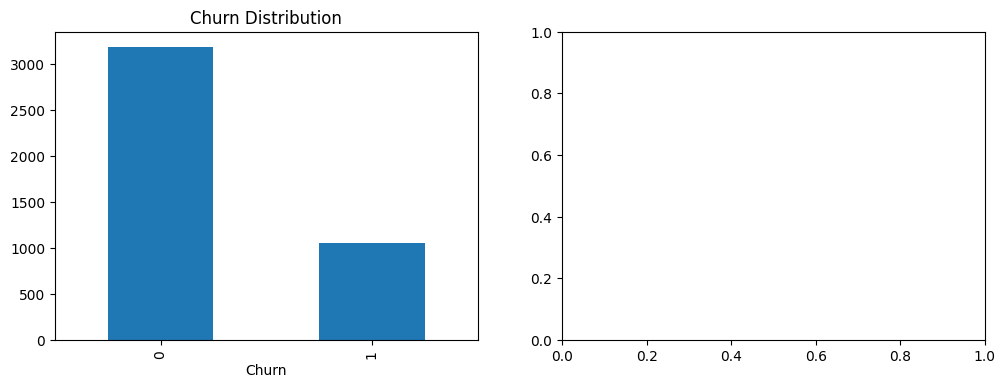

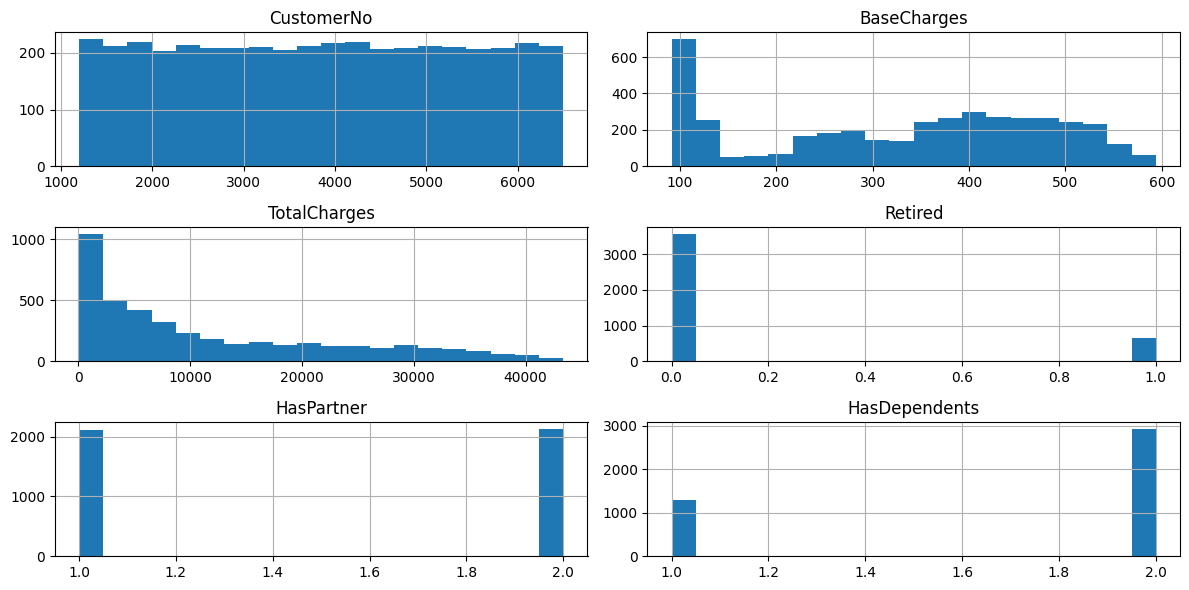

In [21]:
import matplotlib.pyplot as plt, seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train['Churn'].value_counts().plot(kind='bar', ax=axes[0], title='Churn Distribution')

num_cols = train.select_dtypes(include=np.number).columns.drop('Churn', errors='ignore')
train[num_cols].hist(figsize=(12, 6), bins=20)
plt.tight_layout(); plt.show()


In [22]:
ID = 'CustomerNo'
TARGET = 'Churn'

def preprocess(df):
    df = df.drop(columns=[ID], errors='ignore').copy()
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df.fillna(df.median(numeric_only=True), inplace=True)
    for col in df.select_dtypes('object').columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    return df

X = preprocess(train.drop(columns=[TARGET]))
y = train[TARGET].astype(int)
X_test = preprocess(test)


In [23]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost':             xgb.XGBClassifier(n_estimators=300, eval_metric='auc', random_state=42),
    'LightGBM':            lgb.LGBMClassifier(n_estimators=300, random_state=42, verbose=-1),
}

for name, model in models.items():
    score = cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()
    print(f"{name:25s}  AUC: {score:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression        AUC: 0.8360
Random Forest              AUC: 0.8318
XGBoost                    AUC: 0.8103
LightGBM                   AUC: 0.8209


In [24]:
probas = []
for name, model in models.items():
    model.fit(X, y)
    probas.append(model.predict_proba(X_test)[:, 1])

ensemble = np.mean(probas, axis=0)
submission = pd.DataFrame({ID: test[ID], TARGET: (ensemble >= 0.5).astype(int)})
submission.to_csv('submission.csv', index=False)
print(submission[TARGET].value_counts())


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Churn
0    850
1    210
Name: count, dtype: int64


In [26]:
import shutil
shutil.copy('submission.csv', '/content/drive/MyDrive/Colab Notebooks/output/submission.csv')
print("Saved to Drive!")


Saved to Drive!
